# Spaceship Titanic

## Задача

_Необходимо создать модель, способную предсказать: достигнет пассажир другое измерений._

## Импорт библиотек и файлов

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df_test_target = pd.read_csv("data/sample_submission.csv")
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

In [15]:
df_test_target.head()

,PassengerId,Transported
0,0013_01,False
1,0018_01,False
2,0019_01,False
3,0021_01,False
4,0023_01,False


In [16]:
df_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [18]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [17]:
df_test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [19]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
dtypes: float64(6), object(7)
memory usage: 434.5+ KB


## Обозначения

1. `PassengerId` - уникальный **идентификатор** каждого пассажира.
2. `HomePlanet` - **планета**, с которой выехал пассажир.
3. `CryoSleep` - **идентификатор** выбора креосна пассажира во время поездки.
4. `Cabin` - **номер каюты** пассажира.
5. `Destination` - **планета назначения**, на которую отправляется человек.
6. `Age` - **возраст** пассажира.
7. `VIP` - **идентификатор** выбора VIP условий пассажира во время поездки.
8. `RoomService` - **сумма**, которую потратил пассажир на обслуживание в номере во время поездка.
9. `FoodCourt` - **сумма**, которую потратил пассажир на питание во время поездки.
10. `ShoppingMall` - **сумма**, которую потратил пассажир на покупки в торговом центре корабля.
11. `Spa` - **сумма**, которую пассажир потратил на SPA-услуги во время поездки.
12. `VRDeck` - **сумма**, которую пассажир потратил на развлечения во время поездки.
13. `Name` - **Имя** пассажира.

14. `Transported` - целевая переменная; доставлен пассажир или нет в пункт назначения.

## Предварительная обработка и исследование данных

### Работа с выбросами

In [29]:
df_train.corr(numeric_only=True)["Transported"][:-1]

Age            -0.075026
RoomService    -0.244611
FoodCourt       0.046566
ShoppingMall    0.010141
Spa            -0.221131
VRDeck         -0.207075
Name: Transported, dtype: float64

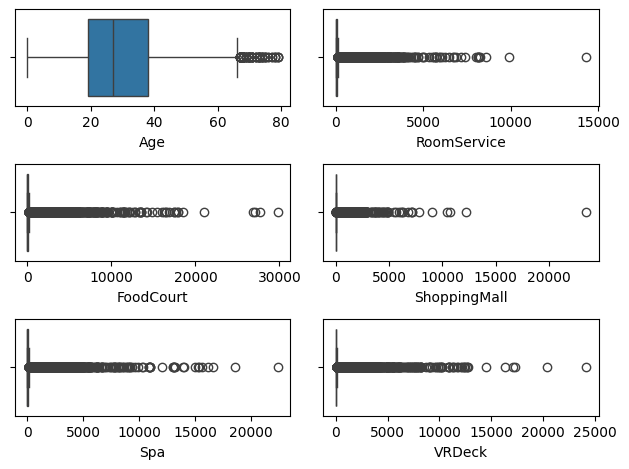

In [54]:
fig, axis = plt.subplots(3, 2)
sns.boxplot(data=df_train, x="Age", ax=axis[0][0])
sns.boxplot(data=df_train, x="RoomService", ax=axis[0][1])
sns.boxplot(data=df_train, x="FoodCourt", ax=axis[1][0])
sns.boxplot(data=df_train, x="ShoppingMall", ax=axis[1][1])
sns.boxplot(data=df_train, x="Spa", ax=axis[2][0])
sns.boxplot(data=df_train, x="VRDeck", ax=axis[2][1])
plt.tight_layout()

Распределение признака `Age` выглядит естественно, а у признаков трат распределение имеет большое количество выбросов справа, создавая тем самым "хвост".

Так как основная доля наблюдение располагается в районе нуля - применять `np.nanpercentile` нельзя, лучше применить `log1p`, чтобы вытянуть хвост и не допустить бесконечности.

In [60]:
features = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]

for col in features:
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

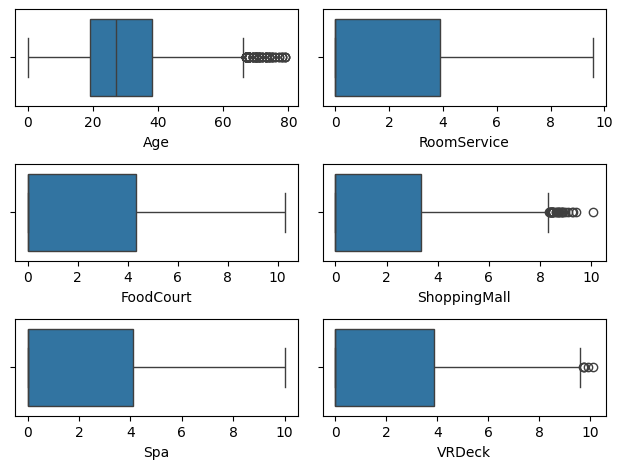

In [61]:
fig, axis = plt.subplots(3, 2)
sns.boxplot(data=df_train, x="Age", ax=axis[0][0])
sns.boxplot(data=df_train, x="RoomService", ax=axis[0][1])
sns.boxplot(data=df_train, x="FoodCourt", ax=axis[1][0])
sns.boxplot(data=df_train, x="ShoppingMall", ax=axis[1][1])
sns.boxplot(data=df_train, x="Spa", ax=axis[2][0])
sns.boxplot(data=df_train, x="VRDeck", ax=axis[2][1])
plt.tight_layout()

In [62]:
df_train.corr(numeric_only=True)["Transported"][:-1]

Age            -0.075026
RoomService    -0.362803
FoodCourt      -0.136035
ShoppingMall   -0.180193
Spa            -0.367705
VRDeck         -0.343462
Name: Transported, dtype: float64

С некоторыми признаками корреляция по целевой переменной уменьшилась в два раза, а с некоторыми поменялся знак.

### Работа с пропусками